In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from src.preprocessing import fit_preprocessing, transform_preprocessor
from src.model_tuning import find_best_xgb_params, find_best_lgbm_params, find_best_cat_params
from src.evaluation import predict_score_plot, compare_roc_graph, feature_importance_plot

C:\Users\melod\anaconda3\envs\aistudy_env\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# 데이터 호출
# df = pd.read_csv("../../01_data/processed/model_df.csv")
df = pd.read_csv('./data/model_df.csv')

In [3]:
# 입력 변수(X)와 타겟 변수(y) 분리
X = df.drop('churned', axis=1)
y = df['churned']

In [4]:
# Train / Test / Validation 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [5]:
# 학습 데이터 기준 전처리 수행 및 검증/테스트 데이터 변환
X_tr_prep, encoders, scaler = fit_preprocessing(X_tr)
X_val_prep = transform_preprocessor(X_val, encoders, scaler)
# X_test_prep = transform_preprocessor(X_test, encoders, scaler)

In [6]:
# 최종 학습용 전처리 (X_train 전체 기준)
X_train_prep_final, encoders_final, scaler_final = fit_preprocessing(X_train)
X_test_prep_final = transform_preprocessor(X_test, encoders_final, scaler_final)

In [7]:
# train용 데이터, 마지막 test용 데이터 튜플화.
train_data = (X_tr_prep, X_val_prep, y_tr, y_val)
test_data = (X_train_prep_final, X_test_prep_final, y_train, y_test)

In [8]:
final_models = []
scores = {}

# XGB

In [9]:
# 탐색할 파라미터 후보 리스트 정의
n_estimators_list_xgb = [100, 200, 300]
learning_rate_list_xgb = [0.01, 0.05, 0.1]
max_depth_list_xgb = [3, 5, 7]
subsample_list_xgb = [0.8, 1.0]
colsample_bytree_list_xgb = [0.8, 1.0]

params_list_xgb = (n_estimators_list_xgb, learning_rate_list_xgb, max_depth_list_xgb, subsample_list_xgb, colsample_bytree_list_xgb)

In [10]:
best_params_xgb = find_best_xgb_params(*train_data, *params_list_xgb)

100%|██████████| 50/50 [00:25<00:00,  1.96trial/s, best loss: -0.8425489858714224]


In [11]:
# 최적의 파라미터로 최종 모델 학습
final_xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    **best_params_xgb
)
final_xgb.fit(X_train_prep_final, y_train)

final_models.append(final_xgb)


XGBClassifier Results
Accuracy : 0.8483
F1 Score : 0.8507
ROC AUC  : 0.9419

HyperOpt가 찾은 최적 파라미터:
- n_estimators: 300
- learning_rate: 0.05
- max_depth: 3
- subsample: 0.8
- colsample_bytree: 1.0


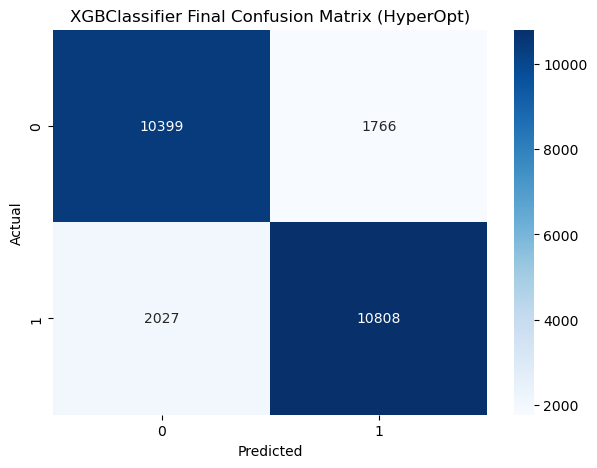

In [12]:
xgb_score = predict_score_plot(final_xgb, best_params_xgb, X_test_prep_final, y_test)
scores['XGBClassifier'] = xgb_score

# LGBM

In [13]:
# LightGBM 탐색 파라미터 후보 정의
n_estimators_list_lgbm = [300, 500, 700, 1000]
learning_rate_list_lgbm = [0.01, 0.03, 0.05, 0.1]
max_depth_list_lgbm = [3, 5, 7, -1]
num_leaves_list_lgbm = [15, 31, 63, 127]
subsample_list_lgbm = [0.8, 1.0]
colsample_bytree_list_lgbm = [0.8, 1.0]

params_list_lgbm = (n_estimators_list_lgbm, learning_rate_list_lgbm, max_depth_list_lgbm, num_leaves_list_lgbm, subsample_list_lgbm, colsample_bytree_list_lgbm)

In [14]:
best_params_lgbm = find_best_lgbm_params(*train_data, *params_list_lgbm)

100%|██████████| 50/50 [01:27<00:00,  1.75s/trial, best loss: -0.8432825233314519]


In [15]:
# 최적 파라미터로 LightGBM 최종 모델 학습
final_lgbm = LGBMClassifier(
    random_state=42,
    verbose=-1,
    n_jobs=-1,
    **best_params_lgbm
)
final_lgbm.fit(X_train_prep_final, y_train)

final_models.append(final_lgbm)


LGBMClassifier Results
Accuracy : 0.8481
F1 Score : 0.8502
ROC AUC  : 0.9420

HyperOpt가 찾은 최적 파라미터:
- n_estimators: 1000
- learning_rate: 0.05
- max_depth: 3
- num_leaves: 63
- subsample: 1.0
- colsample_bytree: 1.0


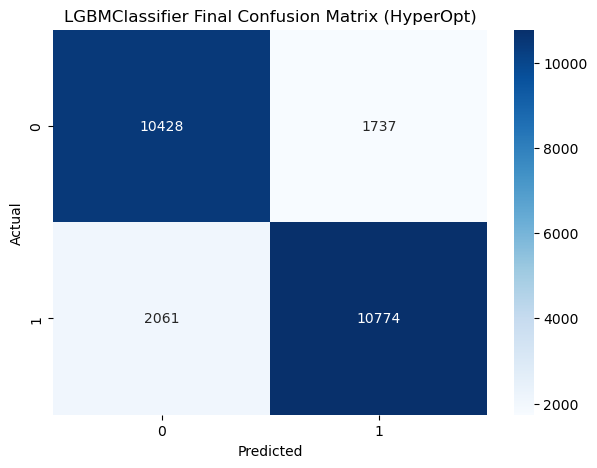

In [16]:
# LightGBM 최종 성능 출력 및 혼동행렬 시각화
lgbm_score = predict_score_plot(final_lgbm, best_params_lgbm, X_test_prep_final, y_test)
scores['LGBMClassifier'] = lgbm_score

# catboost

In [17]:
# CatBoost 탐색 파라미터 후보 정의

iterations_list_cat = [300, 500, 700, 1000]
learning_rate_list_cat = [0.01, 0.03, 0.05, 0.1]
depth_list_cat = [4, 6, 8, 10]
l2_leaf_reg_list_cat = [1, 3, 5, 7, 9]

params_list_cat = (iterations_list_cat, learning_rate_list_cat, depth_list_cat, l2_leaf_reg_list_cat)

In [18]:
best_params_cat = find_best_cat_params(*train_data, *params_list_cat)

100%|██████████| 50/50 [20:10<00:00, 24.21s/trial, best loss: -0.8437884491341989]


In [19]:
# 최적 파라미터로 CatBoost 최종 모델 학습
final_cat = CatBoostClassifier(
    random_state=42,
    verbose=0,
    **best_params_cat
)
final_cat.fit(X_train_prep_final, y_train)

final_models.append(final_cat)


CatBoostClassifier Results
Accuracy : 0.8463
F1 Score : 0.8489
ROC AUC  : 0.9415

HyperOpt가 찾은 최적 파라미터:
- iterations: 1000
- learning_rate: 0.05
- depth: 6
- l2_leaf_reg: 1


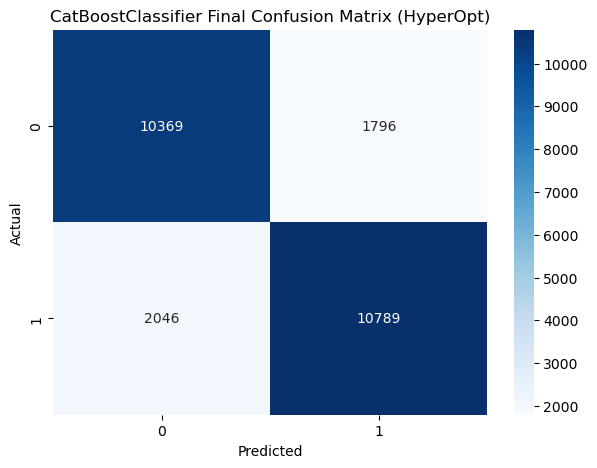

In [20]:
cat_score = predict_score_plot(final_cat, best_params_cat, X_test_prep_final, y_test)
scores['CatBoostClassifier'] = cat_score

# 비교

In [21]:
# Accuracy / F1 / ROC-AUC 비교표 생성
compare_scores_df = pd.DataFrame(scores).T[['accuracy', 'f1', 'roc_auc']]
compare_scores_df

,accuracy,f1,roc_auc
XGBClassifier,0.84828,0.850722,0.941851
LGBMClassifier,0.84808,0.850154,0.941997
CatBoostClassifier,0.84632,0.848859,0.941515


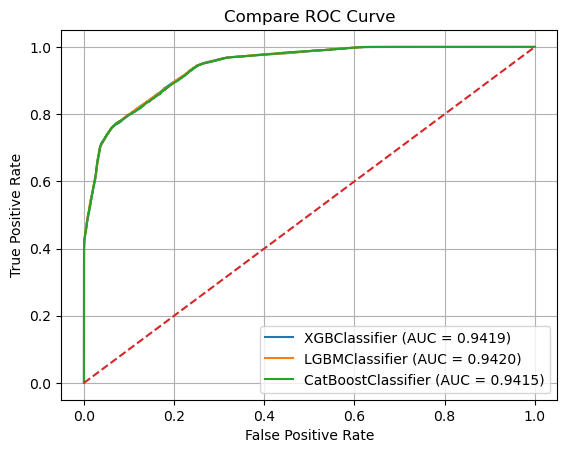

In [22]:
compare_roc_graph(final_models, y_test, scores)

# 최종 선택 모델의 Feature Importance 분석

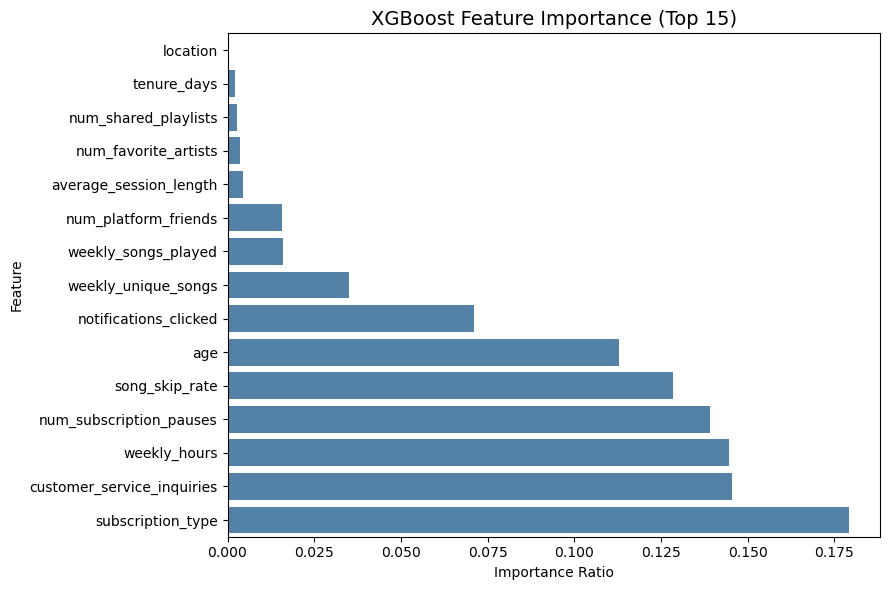

In [23]:
# 최종 선택 모델(XGBoost)의 Feature Importance 분석
final_model = final_xgb
feature_names = X_train.columns

feature_importance_plot(final_model, feature_names)